In [90]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'5000',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)


In [91]:
type(data)

dict

In [92]:
import pandas as pd

In [93]:
pd.set_option('display.max_columns', None)

In [94]:
df = pd.json_normalize(data['data'])
df['timestamp']=pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20035268,20035268,21000000.00,2010-07-13T00:00:00.000Z,12647,1,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,1499536733833.83,"[mineable, pow, sha-256, store-of-value, state...",74844.86,32052962937.49,32022014273.39,30948664.10,-7.62,0.20,-1.21,-3.20,-2.53,12.03,10.63,1499536733833.83,59.67,1571741960751.94,NaN,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
1,1027,Ethereum,ETH,ethereum,True,120685456.18,120685456.18,NaN,2015-08-07T00:00:00.000Z,12006,2,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,247526572174.94,"[pos, smart-contracts, ethereum-ecosystem, coi...",2051.01,13057785321.82,12947628416.74,110156905.09,-17.64,0.26,-0.69,-3.70,-10.36,1.65,1.51,247526572174.94,9.85,247526572174.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
2,825,Tether USDt,USDT,tether,True,189582683099.13,193189782102.16,NaN,2015-02-25T00:00:00.000Z,183292,3,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,192825450098.72,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00,72481949114.36,70990747934.60,1491201179.75,-7.50,-0.03,-0.03,-0.09,-0.19,-0.13,-0.19,189225153637.70,7.53,192825450098.72,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-27 19:13:02.438996
3,1839,BNB,BNB,bnb,False,134784762.09,134784762.09,134784763.20,2017-07-25T00:00:00.000Z,3256,4,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,87908586769.82,"[marketplace, centralized-exchange, payments, ...",652.21,1305170268.21,1278967235.35,26203032.86,-18.25,0.35,-0.38,0.64,4.73,5.90,4.79,87908586769.82,3.50,87908587493.78,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
4,52,XRP,XRP,xrp,False,61858321245,99985662685,100000000000.00,2013-08-04T00:00:00.000Z,1837,5,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,132622250713.54,"[medium-of-exchange, enterprise-solutions, xrp...",1.33,1707330314.05,1706296243.92,1034070.13,1.23,0.58,-0.18,-2.91,-4.85,-1.30,-5.25,82049661607.17,3.26,132641267909.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,36252,AQA,AQA,aqa,False,0,10000000000,10000000000.00,2025-04-16T06:53:22.000Z,4,4996,2026-05-27T19:11:00.000Z,NaN,NaN,804493.00,4363.50,54239120.78,[solana-ecosystem],0.01,536.64,536.64,0.00,98.32,-0.01,-4.12,-8.60,-3.20,469.18,585.08,0.00,0.00,54239120.78,NaN,2026-05-27T19:11:00.000Z,5426.00,solana,Solana,SOL,CHGknFhLgwRcnYGETJwShwAeZssyGE8WXCsgu7fe6X6V,2026-05-27 19:13:02.438996
4996,16821,Mean DAO,MEAN,meanfi,False,0,210000000,NaN,2022-01-04T07:39:05.000Z,24,4997,2026-05-27T19:11:00.000Z,NaN,NaN,105346964.00,3011.90,6003.97,"[ethereum-ecosystem, solana-ecosystem, polygon...",0.00,535.02,535.02,0.00,-0.08,0.02,1.17,1.88,-5.93,-97.47,17.49,0.00,0.00,6003.97,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0x9b25889c493ae6df34ceef1ecb10d77c1ba73318,2026-05-27 19:13:02.438996
4997,18627,Cornatto,CNC,cornatto,False,0,1000000000,1000000000.00,2022-03-08T06:48:31.000Z,5,4998,2026-05-27T19:10:00.000Z,NaN,NaN,1000000000.00,24327.18,24327.18,[tron20-ecosystem],0.00,530.26,530.26,0.00,-0.08,

In [95]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)

df5 = df5.reset_index()
df5

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-1.01
1,Bitcoin,quote.USD.percent_change_24h,-3.01
2,Bitcoin,quote.USD.percent_change_7d,-2.83
3,Bitcoin,quote.USD.percent_change_30d,-3.72
4,Bitcoin,quote.USD.percent_change_60d,12.14
...,...,...,...
29833,TON FISH MEMECOIN,quote.USD.percent_change_24h,-1.97
29834,TON FISH MEMECOIN,quote.USD.percent_change_7d,-6.38
29835,TON FISH MEMECOIN,quote.USD.percent_change_30d,85.78
29836,TON FISH MEMECOIN,quote.USD.percent_change_60d,98.98


In [96]:
df2 = pd.json_normalize(data['data'])
df2['timestamp']=pd.to_datetime('now')
df = pd.concat([df, df2], ignore_index=True)

In [97]:
import os
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()

API Runner completed
API Runner completed


KeyboardInterrupt: 

In [99]:
df


,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20035268,20035268,21000000.00,2010-07-13T00:00:00.000Z,12647,1,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,1499536733833.83,"[mineable, pow, sha-256, store-of-value, state...",74844.86,32052962937.49,32022014273.39,30948664.10,-7.62,0.20,-1.21,-3.20,-2.53,12.03,10.63,1499536733833.83,59.67,1571741960751.94,NaN,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
1,1027,Ethereum,ETH,ethereum,True,120685456.18,120685456.18,NaN,2015-08-07T00:00:00.000Z,12006,2,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,247526572174.94,"[pos, smart-contracts, ethereum-ecosystem, coi...",2051.01,13057785321.82,12947628416.74,110156905.09,-17.64,0.26,-0.69,-3.70,-10.36,1.65,1.51,247526572174.94,9.85,247526572174.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
2,825,Tether USDt,USDT,tether,True,189582683099.13,193189782102.16,NaN,2015-02-25T00:00:00.000Z,183292,3,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,192825450098.72,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00,72481949114.36,70990747934.60,1491201179.75,-7.50,-0.03,-0.03,-0.09,-0.19,-0.13,-0.19,189225153637.70,7.53,192825450098.72,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-27 19:13:02.438996
3,1839,BNB,BNB,bnb,False,134784762.09,134784762.09,134784763.20,2017-07-25T00:00:00.000Z,3256,4,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,87908586769.82,"[marketplace, centralized-exchange, payments, ...",652.21,1305170268.21,1278967235.35,26203032.86,-18.25,0.35,-0.38,0.64,4.73,5.90,4.79,87908586769.82,3.50,87908587493.78,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
4,52,XRP,XRP,xrp,False,61858321245,99985662685,100000000000.00,2013-08-04T00:00:00.000Z,1837,5,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,132622250713.54,"[medium-of-exchange, enterprise-solutions, xrp...",1.33,1707330314.05,1706296243.92,1034070.13,1.23,0.58,-0.18,-2.91,-4.85,-1.30,-5.25,82049661607.17,3.26,132641267909.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,36252,AQA,AQA,aqa,False,0,10000000000,10000000000.00,2025-04-16T06:53:22.000Z,4,4996,2026-05-27T19:11:00.000Z,NaN,NaN,804493.00,4363.50,54239120.78,[solana-ecosystem],0.01,536.64,536.64,0.00,98.32,-0.01,-4.12,-8.60,-3.20,469.18,585.08,0.00,0.00,54239120.78,NaN,2026-05-27T19:11:00.000Z,5426.00,solana,Solana,SOL,CHGknFhLgwRcnYGETJwShwAeZssyGE8WXCsgu7fe6X6V,2026-05-27 19:13:02.615005
9996,16821,Mean DAO,MEAN,meanfi,False,0,210000000,NaN,2022-01-04T07:39:05.000Z,24,4997,2026-05-27T19:11:00.000Z,NaN,NaN,105346964.00,3011.90,6003.97,"[ethereum-ecosystem, solana-ecosystem, polygon...",0.00,535.02,535.02,0.00,-0.08,0.02,1.17,1.88,-5.93,-97.47,17.49,0.00,0.00,6003.97,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0x9b25889c493ae6df34ceef1ecb10d77c1ba73318,2026-05-27 19:13:02.615005
9997,18627,Cornatto,CNC,cornatto,False,0,1000000000,1000000000.00,2022-03-08T06:48:31.000Z,5,4998,2026-05-27T19:10:00.000Z,NaN,NaN,1000000000.00,24327.18,24327.18,[tron20-ecosystem],0.00,530.26,530.26,0.00,-0.08,

In [100]:
if not os.path.isfile(r'C:\R_Files\API.csv'):
  df.to_csv(r'C:\R_Files\API.csv', header='column_names')
else:
  df.to_csv(r'C:\R_Files\API.csv', mode='a', header=False)

In [101]:
df565 = pd.read_csv(r'C:\R_Files\API.csv')

In [102]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [103]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,20035268,20035268,21000000.00,2010-07-13T00:00:00.000Z,12647,1,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,1499536733833.83,"[mineable, pow, sha-256, store-of-value, state...",74844.86,32052962937.49,32022014273.39,30948664.10,-7.62,0.20,-1.21,-3.20,-2.53,12.03,10.63,1499536733833.83,59.67,1571741960751.94,NaN,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
1,1027,Ethereum,ETH,ethereum,True,120685456.18,120685456.18,NaN,2015-08-07T00:00:00.000Z,12006,2,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,247526572174.94,"[pos, smart-contracts, ethereum-ecosystem, coi...",2051.01,13057785321.82,12947628416.74,110156905.09,-17.64,0.26,-0.69,-3.70,-10.36,1.65,1.51,247526572174.94,9.85,247526572174.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
2,825,Tether USDt,USDT,tether,True,189582683099.13,193189782102.16,NaN,2015-02-25T00:00:00.000Z,183292,3,2026-05-27T19:11:00.000Z,NaN,NaN,NaN,NaN,192825450098.72,"[stablecoin, asset-backed-stablecoin, usd-stab...",1.00,72481949114.36,70990747934.60,1491201179.75,-7.50,-0.03,-0.03,-0.09,-0.19,-0.13,-0.19,189225153637.70,7.53,192825450098.72,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-27 19:13:02.438996
3,1839,BNB,BNB,bnb,False,134784762.09,134784762.09,134784763.20,2017-07-25T00:00:00.000Z,3256,4,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,87908586769.82,"[marketplace, centralized-exchange, payments, ...",652.21,1305170268.21,1278967235.35,26203032.86,-18.25,0.35,-0.38,0.64,4.73,5.90,4.79,87908586769.82,3.50,87908587493.78,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
4,52,XRP,XRP,xrp,False,61858321245,99985662685,100000000000.00,2013-08-04T00:00:00.000Z,1837,5,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,132622250713.54,"[medium-of-exchange, enterprise-solutions, xrp...",1.33,1707330314.05,1706296243.92,1034070.13,1.23,0.58,-0.18,-2.91,-4.85,-1.30,-5.25,82049661607.17,3.26,132641267909.94,NaN,2026-05-27T19:12:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-27 19:13:02.438996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,36252,AQA,AQA,aqa,False,0,10000000000,10000000000.00,2025-04-16T06:53:22.000Z,4,4996,2026-05-27T19:11:00.000Z,NaN,NaN,804493.00,4363.50,54239120.78,[solana-ecosystem],0.01,536.64,536.64,0.00,98.32,-0.01,-4.12,-8.60,-3.20,469.18,585.08,0.00,0.00,54239120.78,NaN,2026-05-27T19:11:00.000Z,5426.00,solana,Solana,SOL,CHGknFhLgwRcnYGETJwShwAeZssyGE8WXCsgu7fe6X6V,2026-05-27 19:13:02.615005
9996,16821,Mean DAO,MEAN,meanfi,False,0,210000000,NaN,2022-01-04T07:39:05.000Z,24,4997,2026-05-27T19:11:00.000Z,NaN,NaN,105346964.00,3011.90,6003.97,"[ethereum-ecosystem, solana-ecosystem, polygon...",0.00,535.02,535.02,0.00,-0.08,0.02,1.17,1.88,-5.93,-97.47,17.49,0.00,0.00,6003.97,NaN,2026-05-27T19:11:00.000Z,1027.00,ethereum,Ethereum,ETH,0x9b25889c493ae6df34ceef1ecb10d77c1ba73318,2026-05-27 19:13:02.615005
9997,18627,Cornatto,CNC,cornatto,False,0,1000000000,1000000000.00,2022-03-08T06:48:31.000Z,5,4998,2026-05-27T19:10:00.000Z,NaN,NaN,1000000000.00,24327.18,24327.18,[tron20-ecosystem],0.00,530.26,530.26,0.00,-0.08,

In [104]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.20,-1.21,-3.20,-2.53,12.03,10.63
Ethereum,0.26,-0.69,-3.70,-10.36,1.65,1.51
Tether USDt,-0.03,-0.03,-0.09,-0.19,-0.13,-0.19
BNB,0.35,-0.38,0.64,4.73,5.90,4.79
XRP,0.58,-0.18,-2.91,-4.85,-1.30,-5.25
...,...,...,...,...,...,...
AQA,-0.01,-4.12,-8.60,-3.20,469.18,585.08
Mean DAO,0.02,1.17,1.88,-5.93,-97.47,17.49
Cornatto,0.02,-0.08,0.82,-76.58,70.30,253.14


In [105]:
df4 = df3.stack()
df4

name                                    
Bitcoin     quote.USD.percent_change_1h      0.20
            quote.USD.percent_change_24h    -1.21
            quote.USD.percent_change_7d     -3.20
            quote.USD.percent_change_30d    -2.53
            quote.USD.percent_change_60d    12.03
                                            ...  
Baby Luffy  quote.USD.percent_change_24h    -0.08
            quote.USD.percent_change_7d      0.83
            quote.USD.percent_change_30d   -32.01
            quote.USD.percent_change_60d   113.24
            quote.USD.percent_change_90d   113.24
Length: 29844, dtype: float64

In [106]:
type(df4)

pandas.core.series.Series

In [107]:
df5 = df4.to_frame(name = 'values')

In [108]:
df5

values
name                                           
Bitcoin    quote.USD.percent_change_1h     0.20
           quote.USD.percent_change_24h   -1.21
           quote.USD.percent_change_7d    -3.20
           quote.USD.percent_change_30d   -2.53
           quote.USD.percent_change_60d   12.03
...                                         ...
Baby Luffy quote.USD.percent_change_24h   -0.08
           quote.USD.percent_change_7d     0.83
           quote.USD.percent_change_30d  -32.01
           quote.USD.percent_change_60d  113.24
           quote.USD.percent_change_90d  113.24

[29844 rows x 1 columns]

In [109]:
index = pd.Index(range(len(df5)))
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.20
1,Bitcoin,quote.USD.percent_change_24h,-1.21
2,Bitcoin,quote.USD.percent_change_7d,-3.20
3,Bitcoin,quote.USD.percent_change_30d,-2.53
4,Bitcoin,quote.USD.percent_change_60d,12.03
...,...,...,...
29839,Baby Luffy,quote.USD.percent_change_24h,-0.08
29840,Baby Luffy,quote.USD.percent_change_7d,0.83
29841,Baby Luffy,quote.USD.percent_change_30d,-32.01
29842,Baby Luffy,quote.USD.percent_change_60d,113.24


In [110]:
df7 = df6.rename(columns={'level_1': 'percentage_change'})
df7

,name,percentage_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.20
1,Bitcoin,quote.USD.percent_change_24h,-1.21
2,Bitcoin,quote.USD.percent_change_7d,-3.20
3,Bitcoin,quote.USD.percent_change_30d,-2.53
4,Bitcoin,quote.USD.percent_change_60d,12.03
...,...,...,...
29839,Baby Luffy,quote.USD.percent_change_24h,-0.08
29840,Baby Luffy,quote.USD.percent_change_7d,0.83
29841,Baby Luffy,quote.USD.percent_change_30d,-32.01
29842,Baby Luffy,quote.USD.percent_change_60d,113.24


In [111]:
df7['percentage_change'] = df7['percentage_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percentage_change,values
0,Bitcoin,1h,0.20
1,Bitcoin,24h,-1.21
2,Bitcoin,7d,-3.20
3,Bitcoin,30d,-2.53
4,Bitcoin,60d,12.03
...,...,...,...
29839,Baby Luffy,24h,-0.08
29840,Baby Luffy,7d,0.83
29841,Baby Luffy,30d,-32.01
29842,Baby Luffy,60d,113.24


In [112]:
import seaborn as sns
import matplotlib.pyplot as plt


In [113]:
top_10_name = df7.groupby('name')['values'].max().nlargest(10).index
top_10_df = df7[df7['name'].isin(top_10_name)]

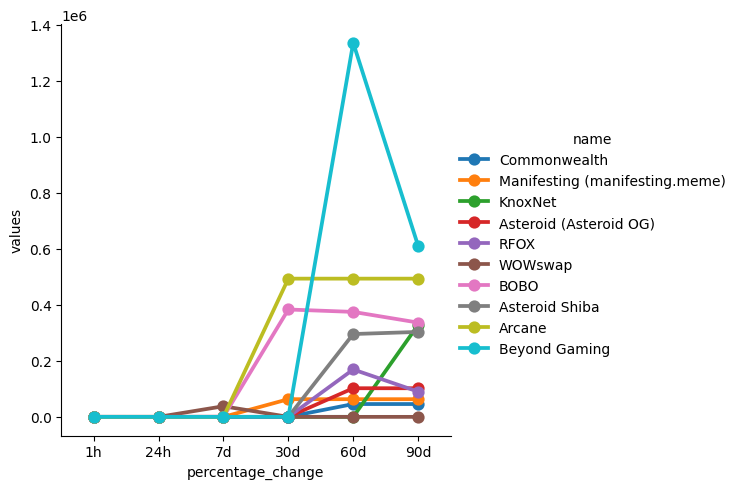

In [114]:
sns.catplot(x='percentage_change', y='values', hue='name', data=top_10_df, kind='point')

In [120]:
df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,74844.86,2026-05-27 19:13:02.438996
5000,Bitcoin,74844.86,2026-05-27 19:13:02.615005


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

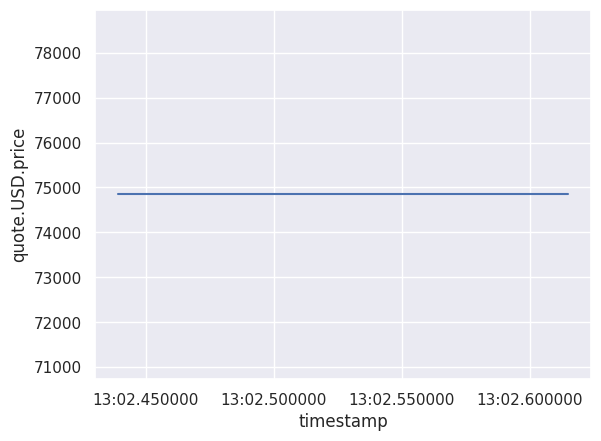

In [121]:
sns.set_theme(style="darkgrid")
sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)